# IMPLEMENTATION OF VANILLA LSTM ARCHITECTURE ON XJTU DATASET

This notebook demonstrates the training and validation of the Vanilla LSTM architecture across multiple window sizes on the XJTU-SY bearing dataset. It features extensive looping over window sizes, caching, error handling, and robust generation of publication-ready visualizations.

In [1]:
import os
import glob
import time
import gc
import re
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler

# Matplotlib Publication Standards
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'lines.linewidth': 2.0,
    'grid.alpha': 0.3
})
sns.set_style("whitegrid")

print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Active GPU: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.5.1+cu121
CUDA Available: True
Active GPU: NVIDIA GeForce RTX 3050 Laptop GPU


## 1. Global Configurations
Centralized hyperparameters, paths, and environment settings. These define the parameters for the LSTM training pipeline.

In [2]:
DATASET_DIR = r"D:\\Proyek Dosen\\Riset Bearing\\Modeling_Inputs"
RESULTS_DIR = r"D:\\Proyek Dosen\\Riset Bearing\\LSTM_Results"

if not os.path.exists(DATASET_DIR):
    print(f"Warning: DATASET_DIR '{DATASET_DIR}' not found. Please verify the path.")
os.makedirs(RESULTS_DIR, exist_ok=True)

# Experiment Setup
WINDOW_SIZES = [30, 40, 50, 70]
NUM_FEATURES = 15

# Training Hyperparameters
EPOCHS = 300
BATCH_SIZE = 128
LEARNING_RATE = 0.001
LSTM_HIDDEN_DIM = 64
LSTM_NUM_LAYERS = 2
DROPOUT = 0.1

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Computation Device: {DEVICE}")

Computation Device: cuda


## 2. Model Architecture
Definition of the Vanilla LSTM Regression Network.

In [3]:
class VanillaLSTM_RUL(nn.Module):
    """
    Vanilla LSTM Neural Network for Remaining Useful Life (RUL) Prediction.
    """
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1, dropout=0.1):
        super(VanillaLSTM_RUL, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_size=input_dim, hidden_size=hidden_dim, 
                            num_layers=num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LeakyReLU(0.1),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, output_dim)
        )
        
    def forward(self, x):
        # x shape: (batch_size, seq_len, input_dim)
        lstm_out, _ = self.lstm(x)
        # Get the output from the last time step
        last_out = lstm_out[:, -1, :]
        out = self.fc(last_out)
        return out

## 3. Evaluation Metrics and Visualization Utilities
Helper functions for error evaluation (RMSE, MAE, R2, Relative Prediction Error) and generating performance graphs.

In [4]:
def calculate_rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def calculate_relative_prediction_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    if not np.any(mask): return 0.0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def scale_health_index_to_rul(hi, max_rul):
    return np.clip(hi, 0, 1) * max_rul

def compute_asymmetric_loss(y_pred, y_true, a=10.0, b=13.0):
    pred_tensor, true_tensor = torch.tensor(y_pred, dtype=torch.float32), torch.tensor(y_true, dtype=torch.float32)
    diff = pred_tensor - true_tensor
    loss = torch.where(diff < 0, torch.exp(-diff / a) - 1, torch.exp(diff / b) - 1)
    return float(loss.mean().item())

def visualize_predictions(y_true, y_pred, title, time_axis=None, turning_point_minute=None, save_path=None):
    """
    Plots expected vs predicted RUL on the absolute-minute X-axis.
    Args:
        time_axis (np.ndarray): Array of absolute minute values from Original_Minute.
        turning_point_minute (int): Absolute minute where degradation starts (Change_Point from metadata).
    """
    x = time_axis if time_axis is not None else np.arange(len(y_true))
    plt.figure(figsize=(12, 6))
    plt.plot(x, y_true, label='Expected RUL', color='black', linestyle='-')
    plt.plot(x, y_pred, label='Predicted RUL', color='gold', linestyle='--')
    
    if turning_point_minute is not None:
        plt.axvline(x=turning_point_minute, color='red', linestyle='-', alpha=0.7,
                    label=f'Turning Point @ Min {turning_point_minute}')
        
    plt.title(title, fontweight='bold')
    plt.xlabel('Absolute Time (Minutes)')
    plt.ylabel('Remaining Useful Life (RUL)')
    plt.legend(loc='upper right')
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()

## 4. Training & Validation Pipeline
Iterates over the defined validation window sizes, training the architecture and extracting test evaluation markers. It dynamically isolates memory usage to prevent Out-Of-Memory (OOM) errors during the loop.

In [5]:
global_summary_metrics = []
excel_export_path = os.path.join(RESULTS_DIR, "LSTM_Predictions_Summary.xlsx")
excel_sheet_buffer = {}

# Load Metadata to extract Total Lifespans (Tf) and Turning Points (Tcp)
metadata_file = os.path.join(DATASET_DIR, "bearing_metadata.csv")
if os.path.exists(metadata_file):
    metadata_df = pd.read_csv(metadata_file)
else:
    print(f"[FATAL ERROR] Metadata file not found at {metadata_file}. Cannot proceed.")
    sys.exit(1)

for window_size in WINDOW_SIZES:
    print(f"\n{'='*60}")
    print(f"STARTING EXPERIMENT FOR WINDOW SIZE: {window_size}")
    print(f"{'='*60}")
    
    window_result_dir = os.path.join(RESULTS_DIR, f"window_size_{window_size}")
    os.makedirs(window_result_dir, exist_ok=True)
    
    training_filepath = os.path.join(DATASET_DIR, f"processed_train_w{window_size}.csv")
    if not os.path.exists(training_filepath):
        print(f"[ERROR] Training payload {training_filepath} missing. Skipping window size {window_size}.")
        continue
        
    print(f"[INFO] Loading training dataset: {training_filepath}")
    df_train = pd.read_csv(training_filepath)
    if df_train.empty:
        print(f'[WARN] Training dataset for WS {window_size} is empty. Skipping...')
        continue
    
    # Use standardized Health Index as target
    y_train_scaled = df_train['Health_Index'].values
    
    # Target Deep Sanitization
    if np.isnan(y_train_scaled).any() or np.isinf(y_train_scaled).any():
        print(f"[DATA LOG] Target HI contains NaN/Inf! Applying nan_to_num recovery.")
        y_train_scaled = np.nan_to_num(y_train_scaled, nan=0.0, posinf=0.0, neginf=0.0)
        
    columns_to_drop = ['Health_Index', 'Target_RUL']
    if 'Bearing_ID' in df_train.columns:
        columns_to_drop.append('Bearing_ID')
    if 'Change_Point' in df_train.columns:
        columns_to_drop.append('Change_Point')
    if 'Original_Minute' in df_train.columns:
        columns_to_drop.append('Original_Minute')
        
    x_train_flat = df_train.drop(columns=columns_to_drop).values
    if np.isnan(x_train_flat).any() or np.isinf(x_train_flat).any():
        print(f"[DATA LOG] Features contain NaN/Inf! Applying nan_to_num recovery.")
        x_train_flat = np.nan_to_num(x_train_flat, nan=0.0, posinf=0.0, neginf=0.0)
        
    # Implement Feature Scaling (RobustScaler)
    from sklearn.preprocessing import RobustScaler    
    num_samples = x_train_flat.shape[0]
    derived_features = x_train_flat.shape[1] // window_size
    x_train_sequences_raw = x_train_flat.reshape(num_samples, derived_features, window_size).transpose(0, 2, 1)
    x_train_sequences_2d = x_train_sequences_raw.reshape(-1, derived_features)
    
    feature_scaler = RobustScaler()
    
    x_train_sequences_scaled_2d = feature_scaler.fit_transform(x_train_sequences_2d)
    x_train_sequences = x_train_sequences_scaled_2d.reshape(num_samples, window_size, derived_features)
    tensor_x_train = torch.tensor(x_train_sequences, dtype=torch.float32).to(DEVICE)
    tensor_y_train = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1).to(DEVICE)
    
    # Memory Management
    del df_train, x_train_flat, x_train_sequences
    gc.collect()
    
    model = VanillaLSTM_RUL(
        input_dim=derived_features,
        hidden_dim=LSTM_HIDDEN_DIM,
        num_layers=LSTM_NUM_LAYERS,
        dropout=DROPOUT
    ).to(DEVICE)
    
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_criterion = nn.MSELoss()
    
    training_dataset = TensorDataset(tensor_x_train, tensor_y_train)
    training_loader = DataLoader(training_dataset, batch_size=BATCH_SIZE, shuffle=True)
    
    print("[INFO] Starting DL Training Phase...")
    model.train()
    
    best_loss_value = float('inf')
    best_model_weights = copy.deepcopy(model.state_dict())
    loss_history_log = []
    
    start_train_time = time.time()
    
    for epoch in range(EPOCHS):
        current_epoch_loss = 0.0
        for batch_input, batch_target in training_loader:
            optimizer.zero_grad()
            predictions = model(batch_input)
            loss_val = loss_criterion(predictions, batch_target)
            loss_val.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            current_epoch_loss += loss_val.item()
        
        average_epoch_loss = current_epoch_loss / len(training_loader)
        loss_history_log.append(average_epoch_loss)
        
        if average_epoch_loss < best_loss_value:
            best_loss_value = average_epoch_loss
            best_model_weights = copy.deepcopy(model.state_dict())
            
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{(epoch+1):03d}/{EPOCHS}] - Training MSE Loss: {average_epoch_loss:.6f}")
            
    train_duration = time.time() - start_train_time
    print(f"[INFO] Training phase finished in {train_duration:.2f} seconds.")
    
    model.load_state_dict(best_model_weights)
    torch.save(model.state_dict(), os.path.join(window_result_dir, "optimized_lstm_model.pth"))
    
    plt.figure(figsize=(10, 5))
    plt.plot(loss_history_log, label='MSE Training Loss', color='red')
    plt.title(f'Continuous Training Loss Optimization (Window: {window_size})')
    plt.xlabel('Epoch Iteration')
    plt.ylabel('MSE Value')
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(window_result_dir, "loss_history_optimization.png"), dpi=300)
    plt.close()
    
    # Memory Management
    del tensor_x_train, tensor_y_train, training_dataset, training_loader
    torch.cuda.empty_cache()
    gc.collect()
    
    # Validation Evaluation
    evaluation_files = glob.glob(os.path.join(DATASET_DIR, f"processed_val_*_w{window_size}.csv"))
    if len(evaluation_files) == 0:
        evaluation_files = glob.glob(os.path.join(DATASET_DIR, f"processed_test_*_w{window_size}.csv"))
        
    if len(evaluation_files) == 0:
        print(f"[WARNING] No evaluation set files targeting window {window_size} were identified!")
        
    regional_predictions_dataframe = pd.DataFrame()
    regional_metrics_log = []
    
    model.eval()
    with torch.no_grad():
        for eval_file_path in evaluation_files:
            regex_match = re.search(r"processed_(?:val|test)_(.*)_w\d+\.csv", os.path.basename(eval_file_path))
            bearing_identity = regex_match.group(1) if regex_match else 'Evaluated_Unknown'
            print(f"[EVAL] Evaluating Sequence Pattern on Domain: {bearing_identity}...")
            
            df_eval = pd.read_csv(eval_file_path)
            if df_eval.empty:
                print(f'[WARN] Evaluation dataset for {bearing_identity} (WS {window_size}) is empty. Skipping...')
                continue
                
            # Load Metadata Configuration for Target Unscaling
            b_meta = metadata_df[metadata_df['Bearing_ID'] == bearing_identity]
            if not b_meta.empty:
                b_tf = float(b_meta['Total_Lifespan'].iloc[0])
                b_tcp = int(b_meta['Change_Point'].iloc[0])
            else:
                print(f"[WARN] Meta info not found for {bearing_identity}, using fallback constants.")
                b_tf = df_eval['Target_RUL'].max()
                b_tcp = 0

            y_true_eval_hi = df_eval['Health_Index'].values
            y_true_eval_rul = df_eval['Target_RUL'].values
            
            eval_drop_limiters = ['Health_Index', 'Target_RUL']
            if 'Bearing_ID' in df_eval.columns: eval_drop_limiters.append('Bearing_ID')
            if 'Change_Point' in df_eval.columns: eval_drop_limiters.append('Change_Point')
            if 'Original_Minute' in df_eval.columns: eval_drop_limiters.append('Original_Minute')
                
            x_eval_flat = df_eval.drop(columns=eval_drop_limiters).values
            x_eval_flat = np.nan_to_num(x_eval_flat, nan=0.0, posinf=0.0, neginf=0.0)
            num_eval_samples = x_eval_flat.shape[0]
            num_eval_features = x_eval_flat.shape[1] // window_size
            x_eval_sequences_raw = x_eval_flat.reshape(num_eval_samples, num_eval_features, window_size).transpose(0, 2, 1)
            x_eval_sequences_2d = x_eval_sequences_raw.reshape(-1, num_eval_features)
            x_eval_sequences_scaled_2d = feature_scaler.transform(x_eval_sequences_2d)
            x_eval_sequences = x_eval_sequences_scaled_2d.reshape(num_eval_samples, window_size, num_eval_features)
            tensor_x_eval = torch.tensor(x_eval_sequences, dtype=torch.float32).to(DEVICE)
            
            start_infer_time = time.time()
            y_pred_eval_hi = model(tensor_x_eval).cpu().numpy().flatten()
            infer_duration = time.time() - start_infer_time
            
            y_pred_eval_hi = np.nan_to_num(y_pred_eval_hi, nan=0.0, posinf=0.0, neginf=0.0)
            
            # Reconstruct RUL
            b_max_rul = b_tf - b_tcp
            y_pred_eval_rul = scale_health_index_to_rul(y_pred_eval_hi, b_max_rul)
            
            rmse_marker = calculate_rmse(y_true_eval_rul, y_pred_eval_rul)
            mae_marker = mean_absolute_error(y_true_eval_rul, y_pred_eval_rul)
            r2_marker = r2_score(y_true_eval_rul, y_pred_eval_rul)
            rpe_marker = calculate_relative_prediction_error(y_true_eval_rul, y_pred_eval_rul)
            asym_marker = compute_asymmetric_loss(y_pred_eval_rul, y_true_eval_rul)
            
            regional_metrics_log.append({
                'Bearing_ID': bearing_identity,
                'Window_Size': window_size,
                'Training_Time(s)': train_duration,
                'Inference_Time(s)': infer_duration,
                'RMSE': rmse_marker,
                'MAE': mae_marker,
                'R2': r2_marker,
                'RPE(%)': rpe_marker,
                'Asymmetric_Loss': asym_marker
            })
            
            if 'Original_Minute' in df_eval.columns:
                time_steps = df_eval['Original_Minute'].values
            else:
                time_steps = np.arange(len(y_true_eval_hi))
                
            bearing_output_frame = pd.DataFrame({
                'Bearing_ID': bearing_identity,
                'Time_Step': time_steps,
                'Expected_Health_Index': y_true_eval_hi,
                'Predicted_Health_Index': y_pred_eval_hi,
                'Expected_Remaining_RUL': y_true_eval_rul,
                'Predicted_Remaining_RUL': y_pred_eval_rul
            })
            regional_predictions_dataframe = pd.concat([regional_predictions_dataframe, bearing_output_frame], ignore_index=True)
            
            graph_title = f"RUL Trajectory ({bearing_identity} | WS: {window_size})"
            graph_save_path = os.path.join(window_result_dir, f"rul_trajectory_{bearing_identity}.png")
            visualize_predictions(y_true_eval_rul, y_pred_eval_rul, graph_title,
                                  time_axis=time_steps, turning_point_minute=b_tcp,
                                  save_path=graph_save_path)
            
            # Memory Management
            del df_eval, x_eval_flat, x_eval_sequences, tensor_x_eval
            gc.collect()
            
    if not regional_predictions_dataframe.empty:
        regional_predictions_dataframe.to_csv(os.path.join(window_result_dir, f"prediction_states_w{window_size}.csv"), index=False)
        excel_sheet_buffer[f"WS_{window_size}"] = regional_predictions_dataframe
        
    if len(regional_metrics_log) > 0:
        regional_metrics_df = pd.DataFrame(regional_metrics_log)
        regional_metrics_df.to_csv(os.path.join(window_result_dir, f"evaluation_markers_w{window_size}.csv"), index=False)
        aggregated_metrics = regional_metrics_df.mean(numeric_only=True)
        
        global_summary_metrics.append({
            'Window_Size': window_size,
            'Mean_RMSE': aggregated_metrics['RMSE'],
            'Mean_MAE': aggregated_metrics['MAE'],
            'Mean_R2': aggregated_metrics['R2'],
            'Mean_RPE(%)': aggregated_metrics['RPE(%)'],
            'Mean_Asymmetric_Loss': aggregated_metrics['Asymmetric_Loss']
        })

print(f"\n[INFO] Consolidating predictions into Global Metrics Workbook: {excel_export_path}")
if len(excel_sheet_buffer) > 0:
    with pd.ExcelWriter(excel_export_path) as xl_writer:
        for sheet_reference, sheet_data in excel_sheet_buffer.items():
            sheet_data.to_excel(xl_writer, sheet_name=sheet_reference, index=False)


STARTING EXPERIMENT FOR WINDOW SIZE: 30
[INFO] Loading training dataset: D:\\Proyek Dosen\\Riset Bearing\\Modeling_Inputs\processed_train_w30.csv
[INFO] Starting DL Training Phase...
Epoch [020/300] - Training MSE Loss: 0.023599
Epoch [040/300] - Training MSE Loss: 0.007218
Epoch [060/300] - Training MSE Loss: 0.003510
Epoch [080/300] - Training MSE Loss: 0.003182
Epoch [100/300] - Training MSE Loss: 0.002534
Epoch [120/300] - Training MSE Loss: 0.002646
Epoch [140/300] - Training MSE Loss: 0.001999
Epoch [160/300] - Training MSE Loss: 0.001978
Epoch [180/300] - Training MSE Loss: 0.002119
Epoch [200/300] - Training MSE Loss: 0.001483
Epoch [220/300] - Training MSE Loss: 0.001899
Epoch [240/300] - Training MSE Loss: 0.001692
Epoch [260/300] - Training MSE Loss: 0.001672
Epoch [280/300] - Training MSE Loss: 0.001457
Epoch [300/300] - Training MSE Loss: 0.001357
[INFO] Training phase finished in 9.69 seconds.
[EVAL] Evaluating Sequence Pattern on Domain: Bearing2_1...
[EVAL] Evaluating 

## 5. Window Size Performance Evaluation
Aggregates evaluations across all setups to discover the optimal structural modeling timeframe and visualizations the RMSE trend across variations.

,Window_Size,Mean_RMSE,Mean_MAE,Mean_R2,Mean_RPE(%),Mean_Asymmetric_Loss
0,30,96.343428,85.076247,-5.030804,235.695408,5.086230e+12
1,40,103.222670,93.682613,-274.358735,426.771212,7.414073e+14
2,50,108.110051,101.529936,-2.391850,177.191671,5.086508e+11
3,70,97.985207,91.557446,-1.945261,185.285800,1.192798e+09


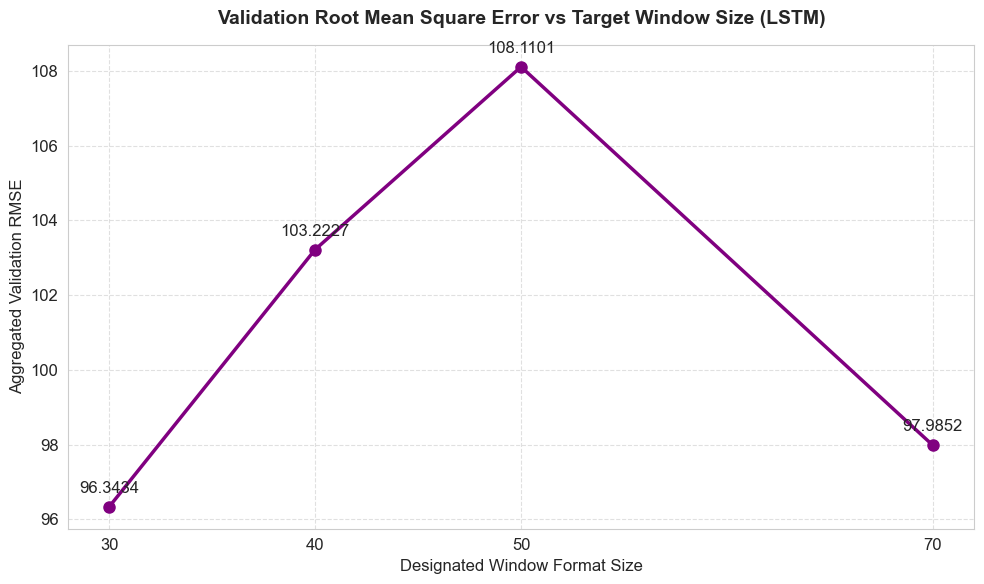


>>> ANALYTICS CONCLUSION: Based on uniform RMSE testing, the optimal structure timeframe is: 30 <<<


In [6]:
summary_dashboard = pd.DataFrame(global_summary_metrics)

if not summary_dashboard.empty:
    display(summary_dashboard)
    summary_dashboard.to_csv(os.path.join(RESULTS_DIR, "LSTM_Global_Window_Comparison.csv"), index=False)
    
    plt.figure(figsize=(10, 6))
    plt.plot(summary_dashboard['Window_Size'], summary_dashboard['Mean_RMSE'], 
             marker='o', linestyle='-', color='purple', linewidth=2.5, markersize=8)
    
    for index, context_row in summary_dashboard.iterrows():
        plt.annotate(f"{context_row['Mean_RMSE']:.4f}", 
                     (context_row['Window_Size'], context_row['Mean_RMSE']),
                     textcoords="offset points", 
                     xytext=(0, 10), 
                     ha='center')
                     
    plt.title('Validation Root Mean Square Error vs Target Window Size (LSTM)', fontweight='bold', pad=15)
    plt.xlabel('Designated Window Format Size')
    plt.ylabel('Aggregated Validation RMSE')
    plt.xticks(summary_dashboard['Window_Size'].values)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, "optimal_rmse_curve_representation.png"), dpi=300)
    plt.show()
    
    optimal_window_size = summary_dashboard.loc[summary_dashboard['Mean_RMSE'].idxmin()]['Window_Size']
    print(f"\n>>> ANALYTICS CONCLUSION: Based on uniform RMSE testing, the optimal structure timeframe is: {int(optimal_window_size)} <<<")
else:
    print(">> Sequence Terminated: No analytical metrics available for overview extraction.")